In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("./Salary Data.csv")
print(df.shape)
print(df.head())
print("=============================")
print(df.tail())
print("=============================")
print(df.info())
print("=============================")
print(df.describe())

(375, 6)
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  
      Age  Gender Education Level                      Job Title  \
370  35.0  Female      Bachelor's       Senior Marketing Analyst   
371  43.0    Male        Master's         Director of Operations   
372  29.0  Female      Bachelor's         Junior Project Manager   
373  34.0    Male      Bachelor's  Senior Operations Coordinator   
374  44.0  Female             PhD        Senior Business Analyst   

     Years of Experience    Salary  
370       

In [31]:
df=df.dropna(subset=['Salary'])
df=df.drop_duplicates()

print(df.isna().sum())
print(df.duplicated().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64
0


In [32]:
from sklearn.model_selection import train_test_split
x=df.drop("Salary",axis=1)
y=df["Salary"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:

print(df.corr(numeric_only=True),
      "\n==========================================\n",
x_train['Gender'].value_counts(normalize=True),
x_train['Education Level'].value_counts(normalize=True),
x_train['Job Title'].value_counts(normalize=True))

                          Age  Years of Experience    Salary
Age                  1.000000             0.979192  0.916543
Years of Experience  0.979192             1.000000  0.924455
Salary               0.916543             0.924455  1.000000 
 Gender
Male      0.540541
Female    0.459459
Name: proportion, dtype: float64 Education Level
Bachelor's    0.594595
Master's      0.274131
PhD           0.131274
Name: proportion, dtype: float64 Job Title
Director of Marketing       0.027027
Director of Operations      0.027027
Senior Marketing Manager    0.023166
Senior Project Manager      0.019305
Senior Financial Analyst    0.019305
                              ...   
Director of Sales           0.003861
Operations Analyst          0.003861
Business Analyst            0.003861
Digital Content Producer    0.003861
Senior Financial Manager    0.003861
Name: proportion, Length: 154, dtype: float64


In [34]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. إعداد الـ Transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[["Bachelor's", "Master's", "PhD"]]), ['Education Level']),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['Gender', 'Job Title'])
    ],
    remainder='passthrough'
)

# 2. التحويل بعد التقسيم
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


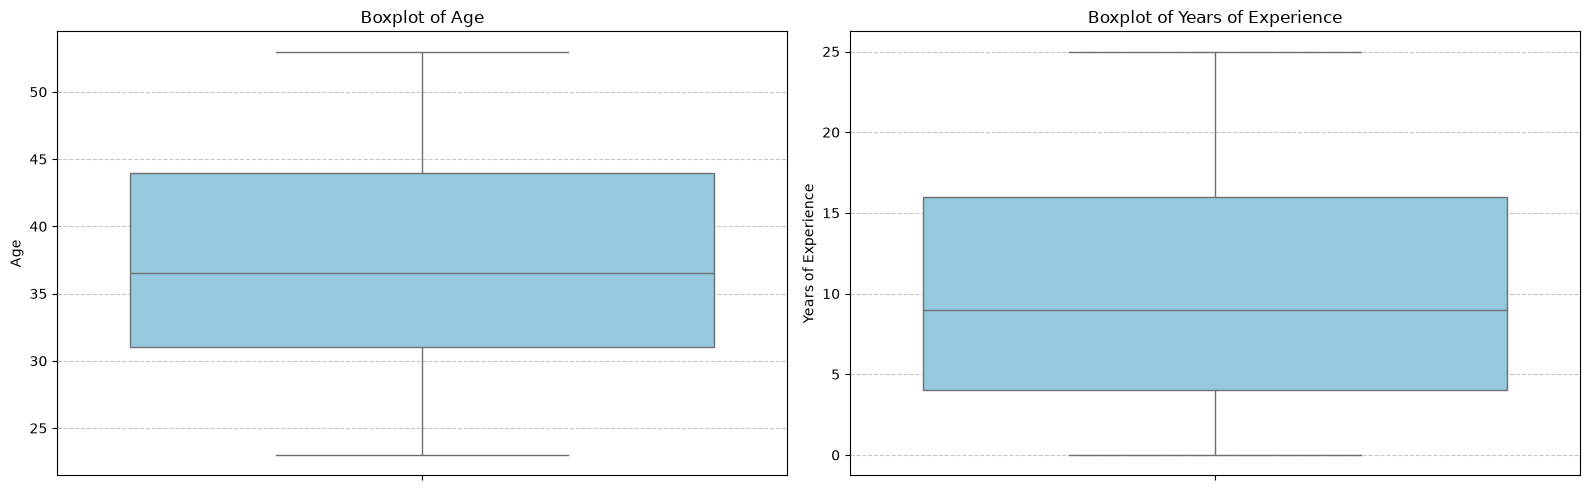

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["Age", "Years of Experience"]


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot of {col}")
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

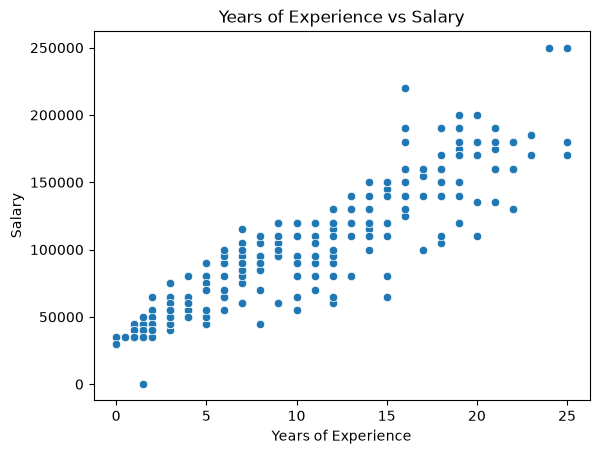

In [36]:
sns.scatterplot(data=df, x="Years of Experience", y="Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")
plt.show()

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

model=LinearRegression()
model.fit(x_train_scaled,y_train)

y_pred=model.predict(x_test_scaled)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2 ): {r2}")


Mean Absolute Error (MAE): 11126.030869761515
Root Mean Squared Error (RMSE): 15349.253052248887
R-squared (R2 ): 0.8753300919759491


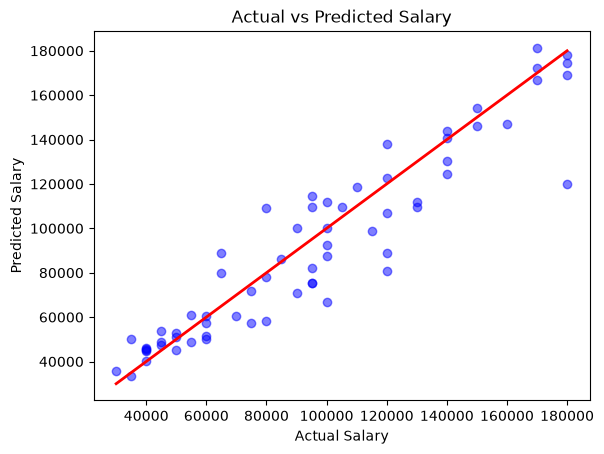

In [38]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.show()